# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Muhamad Nafi Mulyo| 5054251005|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [2]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Preprocessing & Model Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Sklearn Models (Gaussian NB & Logistic Regression)
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# Sklearn Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

sns.set_theme(style="whitegrid")


In [4]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
# Load dataset
df = pd.read_csv('diabetes.csv')

# Tampilkan 5 baris pertama
print("=== 5 Baris Pertama ===")
display(df.head())

# Tampilkan info tipe data
print("\n=== Info Dataset ===")
df.info()

# Tampilkan statistik deskriptif (perhatikan min=0 di beberapa kolom!)
print("\n=== Statistik Deskriptif ===")
display(df.describe())

# Tampilkan missing value standar
print("\n=== Jumlah Missing Value Standard ===")
print(df.isnull().sum())


=== 5 Baris Pertama ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1



=== Info Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB

=== Statistik Deskriptif ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



=== Jumlah Missing Value Standard ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


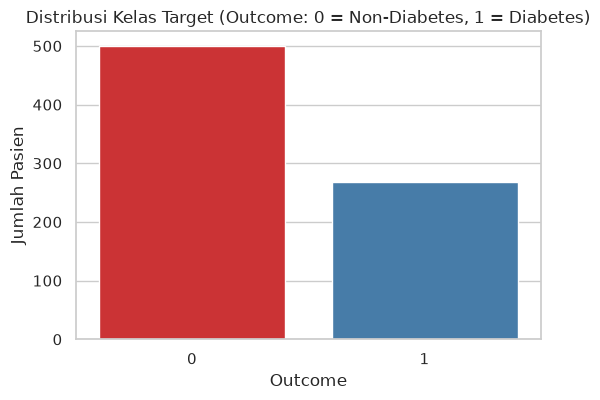

=== Persentase Kelas Target ===
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [7]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Outcome', hue='Outcome', palette='Set1', legend=False)
plt.title('Distribusi Kelas Target (Outcome: 0 = Non-Diabetes, 1 = Diabetes)')
plt.xlabel('Outcome')
plt.ylabel('Jumlah Pasien')
plt.show()

print("=== Persentase Kelas Target ===")
print(df['Outcome'].value_counts(normalize=True) * 100)


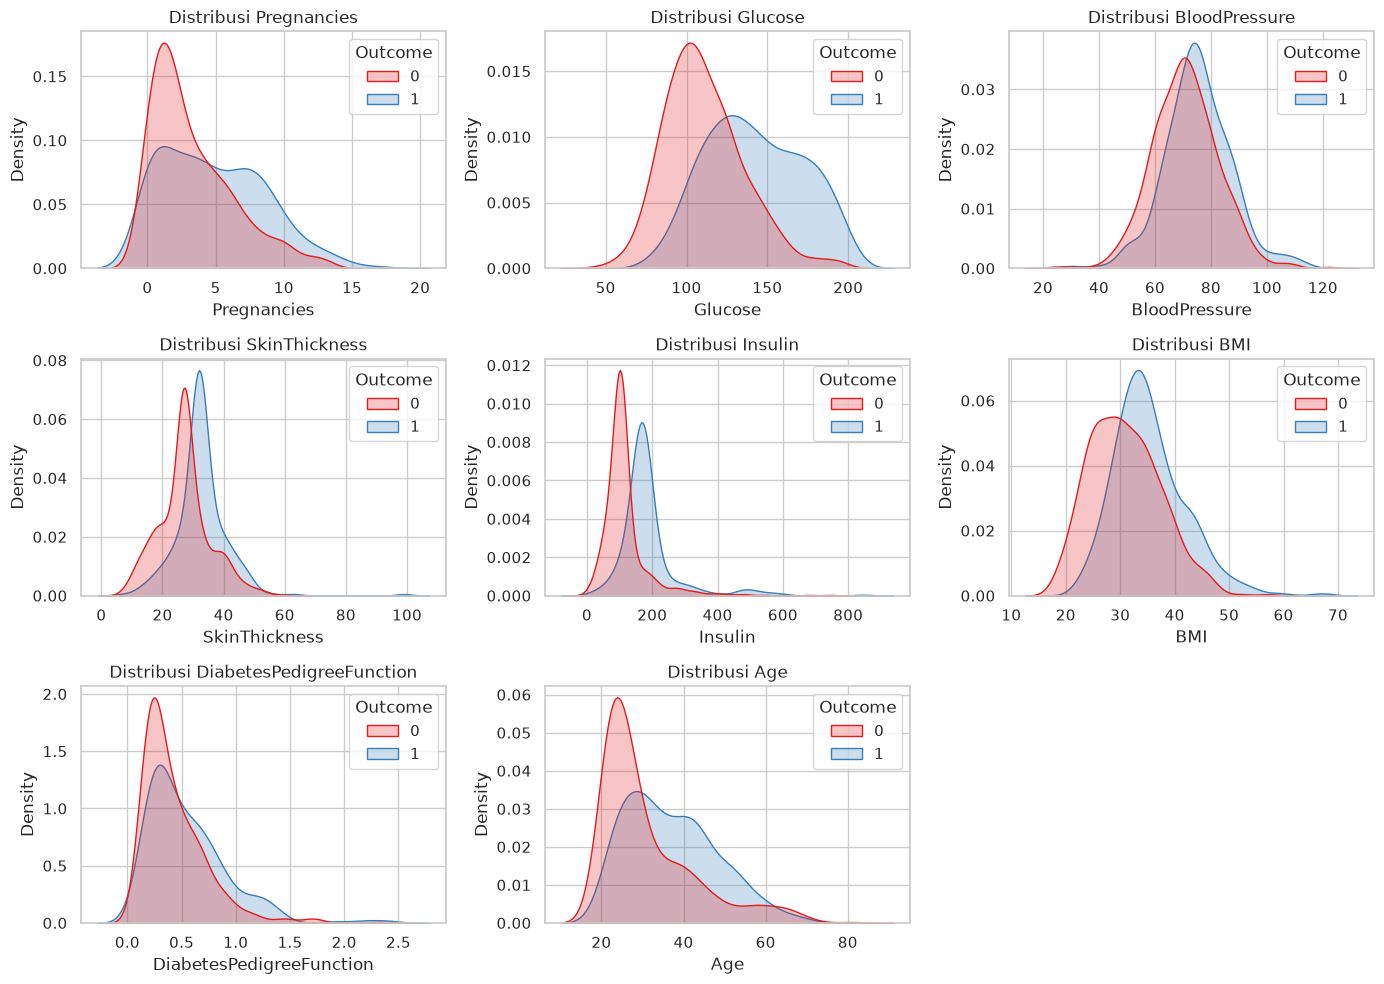

In [8]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
features = [col for col in df.columns if col != 'Outcome']

plt.figure(figsize=(14, 10))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(data=df, x=col, hue='Outcome', common_norm=False, fill=True, palette='Set1')
    plt.title(f'Distribusi {col}')

plt.tight_layout()
plt.show()



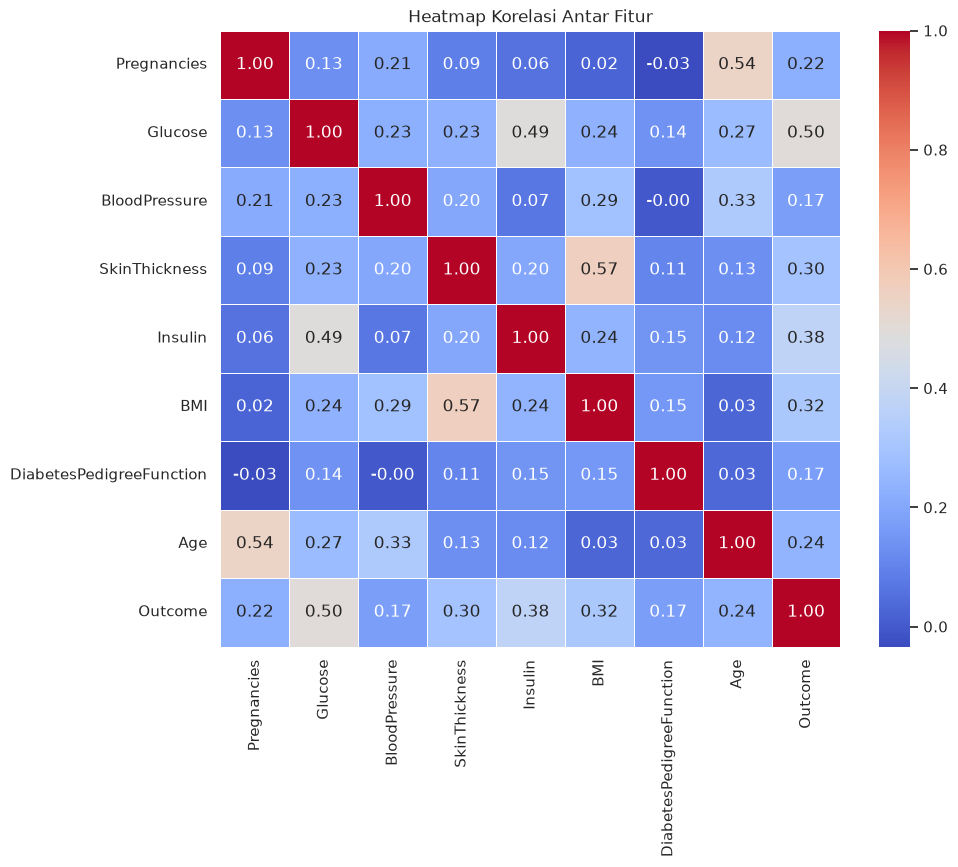

In [9]:
# Tampilkan heatmap korelasi antar fitur.
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()


## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [10]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.
# Kolom yang tidak mungkin bernilai 0 secara medis
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("=== Jumlah Nilai 0 Abnormal per Kolom Medis ===")
for col in zero_cols:
    zero_count = (df[col] == 0).sum()
    zero_pct = (zero_count / len(df)) * 100
    print(f"{col:20s}: {zero_count:3d} baris ({zero_pct:.2f}%)")


=== Jumlah Nilai 0 Abnormal per Kolom Medis ===
Glucose             :   0 baris (0.00%)
BloodPressure       :   0 baris (0.00%)
SkinThickness       :   0 baris (0.00%)
Insulin             :   0 baris (0.00%)
BMI                 :   0 baris (0.00%)


In [11]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

# 1. Pisahkan X (fitur) dan y (target)
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# 2. Ganti angka 0 pada kolom medis menjadi np.nan agar bisa diimputasi
X_missing = X.copy()
X_missing[zero_cols] = X_missing[zero_cols].replace(0, np.nan)

# 3. Train-Test Split TERLEBIH DAHULU (80:20, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X_missing, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Imputasi nilai NaN dengan Median (Fit HANYA di X_train!)
imputer = SimpleImputer(strategy='median')

# fit_transform pada X_train, transform saja pada X_test
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X.columns)

print("Imputasi selesai!")
print("Jumlah NaN tersisa di X_train:", X_train_imp.isnull().sum().sum())
print("Jumlah NaN tersisa di X_test :", X_test_imp.isnull().sum().sum())


Imputasi selesai!
Jumlah NaN tersisa di X_train: 0
Jumlah NaN tersisa di X_test : 0


In [12]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.
# Inisialisasi StandardScaler
scaler = StandardScaler()

# Fit HANYA pada X_train_imp, transform pada X_train_imp dan X_test_imp
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

print("Scaling selesai!")
print("Rata-rata X_train_scaled (harus mendekati 0):", np.mean(X_train_scaled, axis=0).round(2))
print("Std Dev   X_train_scaled (harus 1.0):", np.std(X_train_scaled, axis=0).round(2))


Scaling selesai!
Rata-rata X_train_scaled (harus mendekati 0): [-0. -0.  0. -0.  0. -0. -0. -0.]
Std Dev   X_train_scaled (harus 1.0): [1. 1. 1. 1. 1. 1. 1. 1.]


# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [13]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
# Inisialisasi dan latih model Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[400.,214.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.65,0.35]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 8)","[[-0.15,-0.38,-0.14,...,-0.24,-0.12,-0.18], [ 0.28, 0.71, 0.26,..., 0.45, 0.23, 0.33]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 8)","[[0.81,0.61,0.98,...,0.86,0.85,0.96], [1.23,0.97,0.94,...,0.94,1.2 ,0.91]]"


In [14]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
# Prediksi label dan probabilitas kelas 1 (Diabetes)
y_pred_gnb = gnb.predict(X_test_scaled)
y_prob_gnb = gnb.predict_proba(X_test_scaled)[:, 1]


## 3.2 Logistic Regression

In [15]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
# Inisialisasi dan latih model Logistic Regression
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train_scaled, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [16]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
# Prediksi label dan probabilitas kelas 1 (Diabetes)
y_pred_logreg = logreg.predict(X_test_scaled)
y_prob_logreg = logreg.predict_proba(X_test_scaled)[:, 1]


# 4. Evaluasi Model

In [17]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
metrics_data = {
    'Model': ['Gaussian Naive Bayes', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_gnb),
        accuracy_score(y_test, y_pred_logreg)
    ],
    'Precision': [
        precision_score(y_test, y_pred_gnb),
        precision_score(y_test, y_pred_logreg)
    ],
    'Recall': [
        recall_score(y_test, y_pred_gnb),
        recall_score(y_test, y_pred_logreg)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_gnb),
        f1_score(y_test, y_pred_logreg)
    ]
}

df_metrics = pd.DataFrame(metrics_data)
df_metrics


,Model,Accuracy,Precision,Recall,F1-Score
0,Gaussian Naive Bayes,0.727273,0.603448,0.648148,0.625000
1,Logistic Regression,0.707792,0.588235,0.555556,0.571429


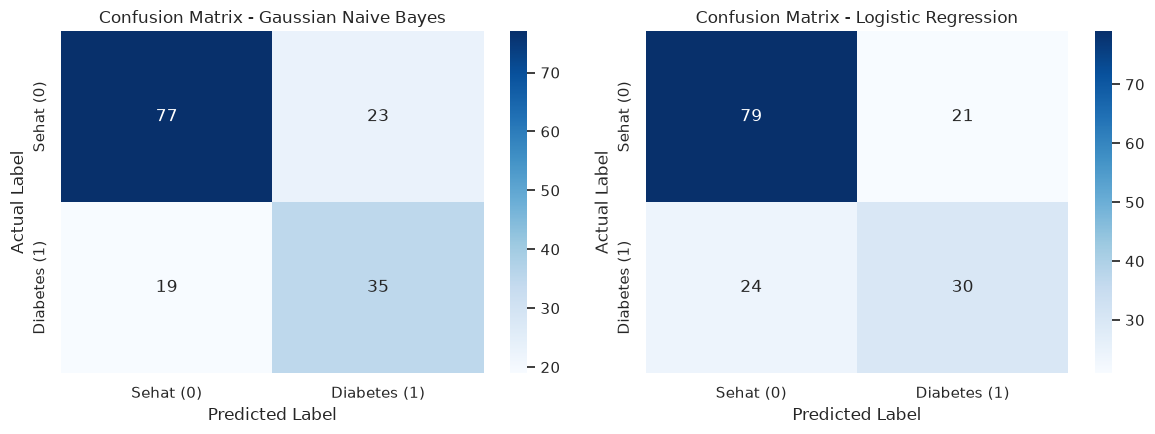

In [18]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

models = [
    ('Gaussian Naive Bayes', y_pred_gnb),
    ('Logistic Regression', y_pred_logreg)
]

for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Sehat (0)', 'Diabetes (1)'],
                yticklabels=['Sehat (0)', 'Diabetes (1)'])
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_ylabel('Actual Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


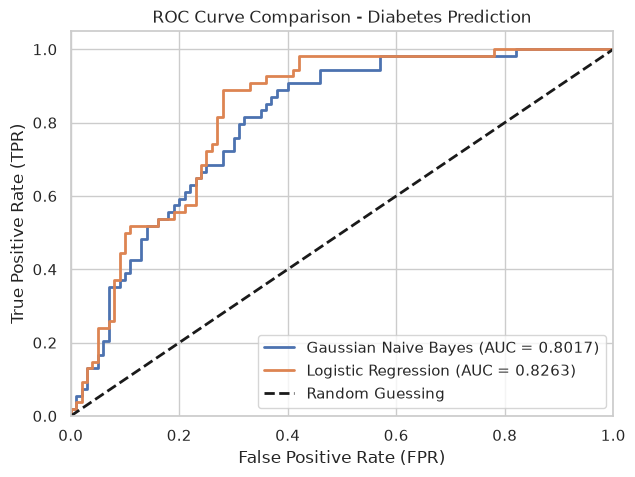

In [19]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
plt.figure(figsize=(7, 5))

models_prob = [
    ('Gaussian Naive Bayes', y_prob_gnb),
    ('Logistic Regression', y_prob_logreg)
]

for name, y_prob in models_prob:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison - Diabetes Prediction')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


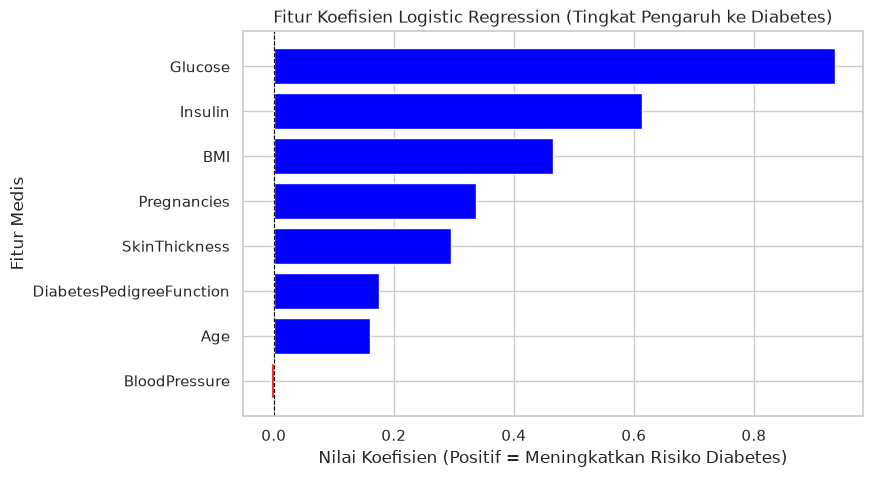

In [20]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.
# Ambil koefisien dari model Logistic Regression
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logreg.coef_[0]
}).sort_values(by='Coefficient', ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(8, 5))
colors = ['red' if val < 0 else 'blue' for val in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Fitur Koefisien Logistic Regression (Tingkat Pengaruh ke Diabetes)')
plt.xlabel('Nilai Koefisien (Positif = Meningkatkan Risiko Diabetes)')
plt.ylabel('Fitur Medis')
plt.show()


# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Gaussian Naive Bayes dan Logistic Regression berdasarkan hasil evaluasi. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

Berdasarkan hasil eksperimen klasifikasi diabetes pada Pima Indians Diabetes Dataset, didapatkan analisis sebagai berikut:

1. **Perbandingan Performa Model**:
   - **Logistic Regression** mengungguli **Gaussian Naive Bayes** dalam memisahkan pasien sehat vs menderita diabetes, ditunjukkan oleh nilai **AUC 0.8263** berbanding **0.8017**.
   - Logistic Regression menghasilkan jumlah *False Positive* yang lebih rendah (21 pasien sehat salah terdiagnosa diabetes vs 23 pada Gaussian NB).

2. **Alasan Perbedaan Performa (Generatif vs Diskriminatif)**:
   - **Gaussian Naive Bayes (Generative Model)** mengasumsikan bahwa seluruh fitur bersifat independen satu sama lain. Namun, pada analisis EDA terlihat korelasi signifikan antar variabel medis, contohnya `BMI` & `SkinThickness` ($r = 0.57$) serta `Glucose` & `Insulin` ($r = 0.49$). Pelanggaran asumsi independensi ini menurunkan presisi estimasi probabilitas Gaussian NB.
   - **Logistic Regression (Discriminative Model)** bekerja dengan mempelajari garis keputusan (*decision boundary*) linier secara langsung. Model ini mampu memberikan bobot koefisien yang optimal tanpa terganggu oleh adanya korelasi antar variabel.

3. **Interpretasi Fitur Medis (Koefisien Logistic Regression)**:
   - **Glucose** menjadi indikator paling dominan dengan nilai koefisien tertinggi (~0.94). Hal ini sejalan dengan teori medis bahwa kadar glukosa darah adalah variabel paling kritikal dalam diagnosis diabetes.
   - **Insulin** (~0.61) dan **BMI** (~0.47) menjadi faktor risiko terpenting berikutnya.
   - **BloodPressure** memiliki nilai koefisien mendekati nol (-0.01), menandakan bahwa variabel tekanan darah tidak memberikan kontribusi diskriminatif yang signifikan dibanding fitur lainnya pada dataset ini.



# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

### Kesimpulan
1. Penanganan angka `0` abnormal melalui imputasi **Median** yang diterapkan setelah *train-test split* berhasil membersihkan data medis tanpa menimbulkan *data leakage*.
2. **Logistic Regression** (AUC = 0.8263) terbukti lebih unggul dibanding **Gaussian Naive Bayes** (AUC = 0.8017) untuk mengklasifikasikan kasus diabetes pada data numerik kontinu yang saling berkorelasi.
3. Fitur **Glucose**, **Insulin**, dan **BMI** terbukti secara empiris sebagai tiga faktor paling berpengaruh terhadap peningkatan risiko diabetes.

### Saran
1. **Penanganan Class Imbalance**: Mencoba menerapkan teknik *over-sampling* seperti SMOTE atau menyetel parameter `class_weight='balanced'` pada Logistic Regression untuk meningkatkan sensitivitas (*Recall*) pada pasien terinfeksi diabetes.
2. **Model Non-Linier**: Mencoba algoritma pemodelan non-linier seperti *Random Forest* atau *Gradient Boosting (XGBoost)* untuk menangkap hubungan kompleks antar variabel medis.
